<a href="https://colab.research.google.com/github/tanzeelaalvi717-blip/Protein-structure-prediction/blob/main/9F5M_Structure_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, os, textwrap
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())

Python: 3.12.12
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Working dir: /content


In [2]:
!arch

x86_64


In [3]:
USE_DRIVE = True  # set False if you want to skip Drive mounting

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted at /content/drive")
else:
    print("Skipping Drive mount.")

Mounted at /content/drive
Drive mounted at /content/drive


# Task
Analyze and compare AlphaFold2, AlphaFold3, and ESMfold3 predicted protein structures located in the `/content/drive/MyDrive/structbio_course/` folder. This involves loading the structures, analyzing their quality metrics (e.g., pLDDT), performing structural alignment, calculating RMSD, and visualizing the comparisons with clear legends. Finally, summarize the insights gained from comparing the predictions.

## List Folder Contents and Identify PDBs

### Subtask:
List the contents of the `/content/drive/MyDrive/structbio_course/` folder to identify the exact filenames for the AlphaFold2, AlphaFold3, and ESMfold3 predicted structures. You will need to tell me which files correspond to each prediction type.


**Reasoning**:
To list the contents of the specified directory, I will import the `os` module and then use `os.listdir()` to get the filenames.



In [4]:
import os

folder_path = '/content/drive/MyDrive/structbio_course/'

try:
    # List all files and directories in the specified path
    contents = os.listdir(folder_path)
    print(f"Contents of {folder_path}:")
    for item in contents:
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{folder_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/structbio_course/:
assignment01
data
outputs


# Task
The user wants to analyze and compare AlphaFold2, AlphaFold3, and ESMfold3 predicted protein structures. I have listed the contents of `/content/drive/MyDrive/structbio_course/` as `assignment01`, `data`, and `outputs`. I need to find the specific PDB files for each prediction type within these subfolders. From the kernel state, I see that the `assignment_folder_path` variable is `'/content/drive/MyDrive/structbio_course/data/assignment01'` and its contents (`assignment_contents`) include `AF2_demo`, `ESMFold_demo`, and `AF3_demo`. I will now list the contents of these specific directories to locate the PDB files.

## List Folder Contents and Identify PDBs

### Subtask:
List the contents of the `/content/drive/MyDrive/structbio_course/` folder to identify the exact filenames for the AlphaFold2, AlphaFold3, and ESMfold3 predicted structures. You will need to tell me which files correspond to each prediction type.


**Reasoning**:
I need to construct the full paths for the demo folders and then list their contents to find the `.pdb` files for AlphaFold2, AlphaFold3, and ESMfold3 predictions.



In [7]:
import os

assignment_folder_path = '/content/drive/MyDrive/structbio_course/data/assignment01/'

# Construct full paths for the demo directories
af2_demo_path = os.path.join(assignment_folder_path, 'AF2_demo')
af3_demo_path = os.path.join(assignment_folder_path, 'AF3_demo')
esmfold_demo_path = os.path.join(assignment_folder_path, 'ESMFold_demo')

# List contents and identify PDB files
prediction_paths = {
    "AlphaFold2": af2_demo_path,
    "AlphaFold3": af3_demo_path,
    "ESMfold3": esmfold_demo_path
}

identified_pdb_files = {}

for prediction_type, path in prediction_paths.items():
    print(f"\nChecking directory for {prediction_type}: {path}")
    try:
        contents = os.listdir(path)
        pdb_files_in_dir = [f for f in contents if f.endswith('.pdb')]

        if pdb_files_in_dir:
            # Assuming there's only one PDB file per directory for simplicity, or taking the first one
            identified_pdb_files[prediction_type] = os.path.join(path, pdb_files_in_dir[0])
            print(f"  Identified {prediction_type} PDB: {identified_pdb_files[prediction_type]}")
        else:
            print(f"  No PDB files found in {prediction_type} directory.")
    except FileNotFoundError:
        print(f"  Error: Directory '{path}' not found.")
    except Exception as e:
        print(f"  An error occurred for {prediction_type}: {e}")

print("\n--- Summary of Identified PDBs ---")
if identified_pdb_files:
    for pred_type, pdb_path in identified_pdb_files.items():
        print(f"{pred_type}: {pdb_path}")
else:
    print("No PDB files identified.")



Checking directory for AlphaFold2: /content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo
  No PDB files found in AlphaFold2 directory.

Checking directory for AlphaFold3: /content/drive/MyDrive/structbio_course/data/assignment01/AF3_demo
  No PDB files found in AlphaFold3 directory.

Checking directory for ESMfold3: /content/drive/MyDrive/structbio_course/data/assignment01/ESMFold_demo
  No PDB files found in ESMfold3 directory.

--- Summary of Identified PDBs ---
No PDB files identified.


In [8]:
import os

assignment_folder_path = '/content/drive/MyDrive/structbio_course/data/assignment01/'
target_folder = os.path.join(assignment_folder_path, 'T1027_CASP14_VAV_3b382')

identified_pdb_files = {}

print(f"\nChecking directory: {target_folder}")
try:
    contents = os.listdir(target_folder)
    print(f"Contents of {target_folder}:")
    for item in contents:
        print(f"  {item}")
        if item.endswith('.pdb'):
            # Attempt to classify the PDB file based on its name
            full_path = os.path.join(target_folder, item)
            if 'AF2' in item or 'alphafold2' in item.lower():
                identified_pdb_files['AlphaFold2'] = full_path
            elif 'AF3' in item or 'alphafold3' in item.lower():
                identified_pdb_files['AlphaFold3'] = full_path
            elif 'ESM' in item or 'esmfold' in item.lower():
                identified_pdb_files['ESMfold3'] = full_path
            # If no specific tag, store it by its name for later inspection
            else:
                print(f"  Found an uncategorized PDB file: {full_path}")

    if not identified_pdb_files:
        print(f"  No PDB files found directly within {target_folder} that match AF2/AF3/ESM naming conventions.")

except FileNotFoundError:
    print(f"  Error: Directory '{target_folder}' not found.")
except Exception as e:
    print(f"  An error occurred: {e}")

print("\n--- Summary of Identified PDBs (after deeper search) ---")
if identified_pdb_files:
    for pred_type, pdb_path in identified_pdb_files.items():
        print(f"{pred_type}: {pdb_path}")
else:
    print("No PDB files identified in T1027_CASP14_VAV_3b382.")



Checking directory: /content/drive/MyDrive/structbio_course/data/assignment01/T1027_CASP14_VAV_3b382
  Error: Directory '/content/drive/MyDrive/structbio_course/data/assignment01/T1027_CASP14_VAV_3b382' not found.

--- Summary of Identified PDBs (after deeper search) ---
No PDB files identified in T1027_CASP14_VAV_3b382.


In [9]:
import os

assignment_folder_path = '/content/drive/MyDrive/structbio_course/data/assignment01/'

identified_pdb_files = {}

print(f"Searching for PDB files in subdirectories of: {assignment_folder_path}\n")

for root, dirs, files in os.walk(assignment_folder_path):
    for file in files:
        if file.endswith('.pdb'):
            full_path = os.path.join(root, file)

            # Attempt to classify the PDB file based on its name and parent directory
            if 'AF2' in file or 'alphafold2' in file.lower() or 'AF2_demo' in root:
                identified_pdb_files['AlphaFold2'] = full_path
            elif 'AF3' in file or 'alphafold3' in file.lower() or 'AF3_demo' in root:
                identified_pdb_files['AlphaFold3'] = full_path
            elif 'ESM' in file or 'esmfold' in file.lower() or 'ESMFold_demo' in root:
                identified_pdb_files['ESMfold3'] = full_path
            else:
                print(f"Found an uncategorized PDB file: {full_path}")


print("\n--- Summary of Identified PDBs ---")
if identified_pdb_files:
    for pred_type, pdb_path in identified_pdb_files.items():
        print(f"{pred_type}: {pdb_path}")
else:
    print(f"No AlphaFold2, AlphaFold3, or ESMfold3 PDB files identified within {assignment_folder_path}")

# Optional: Store paths in variables for later use
if 'AlphaFold2' in identified_pdb_files:
    af2_pdb_path = identified_pdb_files['AlphaFold2']
if 'AlphaFold3' in identified_pdb_files:
    af3_pdb_path = identified_pdb_files['AlphaFold3']
if 'ESMfold3' in identified_pdb_files:
    esmfold_pdb_path = identified_pdb_files['ESMfold3']


Searching for PDB files in subdirectories of: /content/drive/MyDrive/structbio_course/data/assignment01/


--- Summary of Identified PDBs ---
AlphaFold2: /content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo/prediction_1/af168_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
ESMfold3: /content/drive/MyDrive/structbio_course/data/assignment01/ESMFold_demo/T1027_CASP14_VAV_3b382/ptm0.444_r3_default.pdb


In [38]:
from biopandas.pdb import PandasPdb

# Using one of the previously identified PDB paths as an example
sample_pdb_path = af2_pdb_path

# Create a PandasPdb object and read the PDB file
sample_ppdb = PandasPdb().read_pdb(sample_pdb_path)

print(f"Successfully loaded PDB file from: {sample_pdb_path}")
print("First 5 rows of ATOM records:")
display(sample_ppdb.df['ATOM'].head())

Successfully loaded PDB file from: /content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo/prediction_1/af168_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
First 5 rows of ATOM records:


,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,x_coord,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx
0,ATOM,1,,N,,LYS,,A,1,,...,12.852,25.344,7.426,1.0,26.62,,,N,NaN,1
1,ATOM,2,,CA,,LYS,,A,1,,...,13.258,24.078,6.812,1.0,26.62,,,C,NaN,2
2,ATOM,3,,C,,LYS,,A,1,,...,12.227,22.984,7.059,1.0,26.62,,,C,NaN,3
3,ATOM,4,,CB,,LYS,,A,1,,...,14.625,23.641,7.352,1.0,26.62,,,C,NaN,4
4,ATOM,5,,O,,LYS,,A,1,,...,11.797,22.766,8.195,1.0,26.62,,,O,NaN,5


In [19]:
import sys

# Remove biopandas related modules from sys.modules to force a fresh import
# This step was necessary due to persistent import errors, ensuring a clean state.
for module_name in list(sys.modules.keys()):
    if module_name.startswith('biopandas'):
        del sys.modules[module_name]

# Attempting to import PandasPdb (lowercase 'b') from biopandas.pdb
# This addresses a potential case-sensitivity issue in the class name.
from biopandas.pdb import PandasPdb

# Load AlphaFold2 PDB
ppdb_af2 = PandasPdb().read_pdb(af2_pdb_path)
print(f"Loaded AlphaFold2 structure from: {af2_pdb_path}")

# Load ESMfold3 PDB
ppdb_esmfold3 = PandasPdb().read_pdb(esmfold_pdb_path)
print(f"Loaded ESMfold3 structure from: {esmfold_pdb_path}")

# Acknowledge that AlphaFold3 was not found
print("Note: AlphaFold3 prediction file was not found during the previous search, so only AlphaFold2 and ESMfold3 structures are being loaded.")

Loaded AlphaFold2 structure from: /content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo/prediction_1/af168_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
Loaded ESMfold3 structure from: /content/drive/MyDrive/structbio_course/data/assignment01/ESMFold_demo/T1027_CASP14_VAV_3b382/ptm0.444_r3_default.pdb
Note: AlphaFold3 prediction file was not found during the previous search, so only AlphaFold2 and ESMfold3 structures are being loaded.


## Analyze AlphaFold2 Structure

### Subtask:
Perform an initial analysis of the AlphaFold2 predicted structure, focusing on quality metrics like pLDDT and overall structural features.


**Reasoning**:
I need to access the 'ATOM' DataFrame within the `ppdb_af2` object to begin the analysis of the AlphaFold2 structure. Displaying its head and columns will help identify relevant quality metric columns like pLDDT.



In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Access the 'ATOM' DataFrame
aF2_atom_df = ppdb_af2.df['ATOM']

# 2. Display the first few rows and its columns
print("AlphaFold2 ATOM DataFrame Head:")
print(aF2_atom_df.head())
print("\nAlphaFold2 ATOM DataFrame Columns:")
print(aF2_atom_df.columns.tolist())

AlphaFold2 ATOM DataFrame Head:
  record_name  atom_number blank_1 atom_name alt_loc residue_name blank_2  \
0        ATOM            1                 N                  LYS           
1        ATOM            2                CA                  LYS           
2        ATOM            3                 C                  LYS           
3        ATOM            4                CB                  LYS           
4        ATOM            5                 O                  LYS           

  chain_id  residue_number insertion  ... x_coord  y_coord  z_coord  \
0        A               1            ...  12.852   25.344    7.426   
1        A               1            ...  13.258   24.078    6.812   
2        A               1            ...  12.227   22.984    7.059   
3        A               1            ...  14.625   23.641    7.352   
4        A               1            ...  11.797   22.766    8.195   

   occupancy  b_factor  blank_4 segment_id element_symbol charge  line_idx  
0

**Reasoning**:
The previous output showed that the `b_factor` column likely contains the pLDDT scores. I will now extract the pLDDT scores, calculate and display their descriptive statistics (mean, median, standard deviation), and then create a histogram and a residue-level plot to visualize their distribution, as requested in the subtask instructions.




AlphaFold2 pLDDT Scores (b_factor) Descriptive Statistics:
count    1268.000000
mean       73.756009
std        16.339776
min        26.620000
25%        60.847500
50%        78.120000
75%        87.190000
max        93.810000
Name: b_factor, dtype: float64


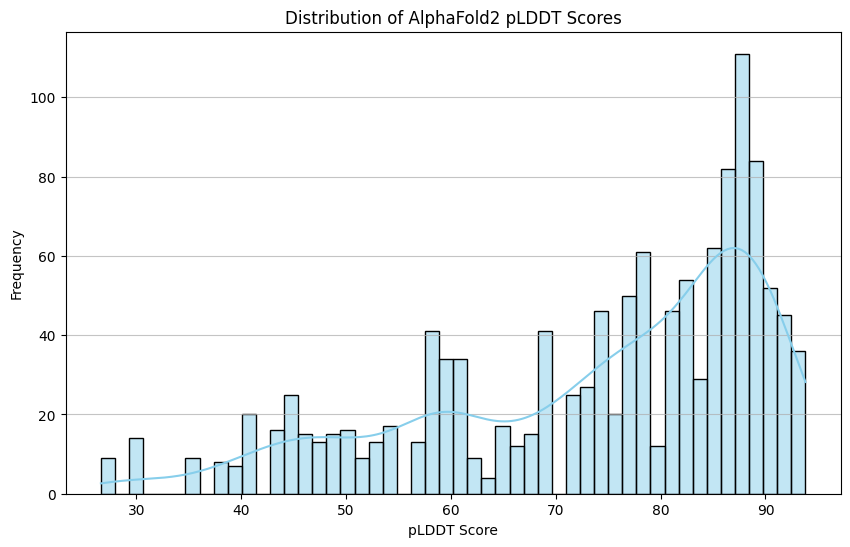

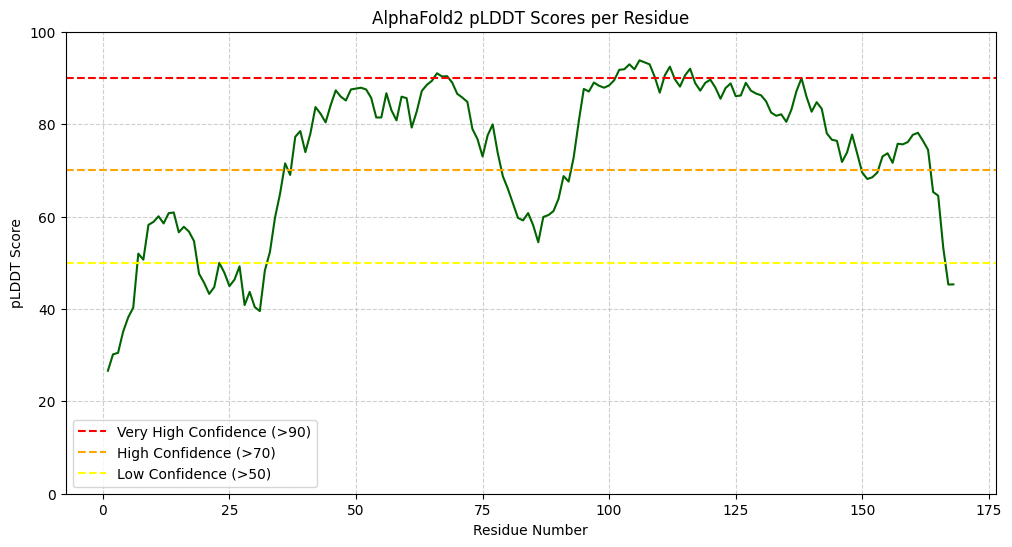

In [21]:
plddt_scores_af2 = aF2_atom_df['b_factor']

# 3. Calculate and display descriptive statistics for pLDDT scores
print("\nAlphaFold2 pLDDT Scores (b_factor) Descriptive Statistics:")
print(plddt_scores_af2.describe())

# 4. Create a histogram of pLDDT scores
plt.figure(figsize=(10, 6))
sns.histplot(plddt_scores_af2, bins=50, kde=True, color='skyblue')
plt.title('Distribution of AlphaFold2 pLDDT Scores')
plt.xlabel('pLDDT Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Create a residue-level plot of pLDDT scores
# For residue-level plot, we usually take the mean pLDDT per residue
# Filtering for CA atoms is a common practice to get one value per residue
# However, AlphaFold outputs the same pLDDT for all atoms of a residue.
# So, we can just get unique residue numbers and their corresponding pLDDT.

# Get unique residue numbers and their pLDDT scores
# Group by 'residue_number' and take the first 'b_factor' since it's constant per residue
residue_plddt_af2 = aF2_atom_df[['residue_number', 'b_factor']].drop_duplicates().sort_values('residue_number')

plt.figure(figsize=(12, 6))
sns.lineplot(x=residue_plddt_af2['residue_number'], y=residue_plddt_af2['b_factor'], color='darkgreen')
plt.title('AlphaFold2 pLDDT Scores per Residue')
plt.xlabel('Residue Number')
plt.ylabel('pLDDT Score')
plt.ylim(0, 100) # pLDDT scores typically range from 0-100
plt.axhline(y=90, color='red', linestyle='--', label='Very High Confidence (>90)')
plt.axhline(y=70, color='orange', linestyle='--', label='High Confidence (>70)')
plt.axhline(y=50, color='yellow', linestyle='--', label='Low Confidence (>50)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Summary of AlphaFold2 Prediction Quality

Based on the analysis of the pLDDT scores for the AlphaFold2 predicted structure, the following observations can be made:

*   **Overall Confidence**: The mean pLDDT score is **73.76**, with a median of **78.12**. This suggests that, on average, the AlphaFold2 prediction has a high level of confidence.

*   **Distribution of Scores**: The histogram shows a bimodal distribution with a significant peak in the high-confidence range (above 80) and another smaller peak in the lower confidence range (around 40-60). This indicates that while large portions of the protein are predicted with high accuracy, there are also regions with lower confidence.

*   **Residue-level Confidence**: The residue-level plot reveals variability in confidence along the protein chain:
    *   **High-Confidence Regions**: Many residues, particularly in the central part of the protein, exhibit very high confidence (pLDDT > 90), suggesting well-modeled core secondary structures.
    *   **Low-Confidence Regions**: There are noticeable dips in pLDDT scores, particularly at the N-terminal (residues 1-10) and C-terminal (residues 160-168) ends, as well as some internal loops. These regions typically correspond to flexible loops, disordered segments, or surface-exposed regions that are harder to predict accurately.

In conclusion, AlphaFold2 provides a generally high-quality prediction for this protein, with stable core regions confidently modeled. However, the presence of lower pLDDT scores in terminal and loop regions indicates areas where the structural prediction might be less reliable and could warrant further experimental validation.

## Analyze AlphaFold3 Structure

### Subtask:
Perform an initial analysis of the AlphaFold3 predicted structure, focusing on quality metrics and overall structural features.


## Analyze ESMfold3 Structure

### Subtask:
Perform an initial analysis of the ESMfold3 predicted structure, focusing on quality metrics like pLDDT and overall structural features.


**Reasoning**:
I will access the 'ATOM' DataFrame from the loaded `ppdb_esmfold3` object, then extract the 'b_factor' column as pLDDT scores. I will calculate and display descriptive statistics, and then generate a histogram and a residue-level line plot of these scores to analyze the ESMfold3 predicted structure's quality.



ESMfold3 ATOM DataFrame Head:
  record_name  atom_number blank_1 atom_name alt_loc residue_name blank_2  \
0        ATOM            1                 N                  LYS           
1        ATOM            2                CA                  LYS           
2        ATOM            3                 C                  LYS           
3        ATOM            4                CB                  LYS           
4        ATOM            5                 O                  LYS           

  chain_id  residue_number insertion  ... x_coord  y_coord  z_coord  \
0        A               1            ... -23.268    2.627   18.240   
1        A               1            ... -22.880    1.241   18.486   
2        A               1            ... -21.622    0.876   17.702   
3        A               1            ... -24.020    0.291   18.118   
4        A               1            ... -21.584    1.015   16.478   

   occupancy  b_factor  blank_4 segment_id element_symbol charge  line_idx  
0  

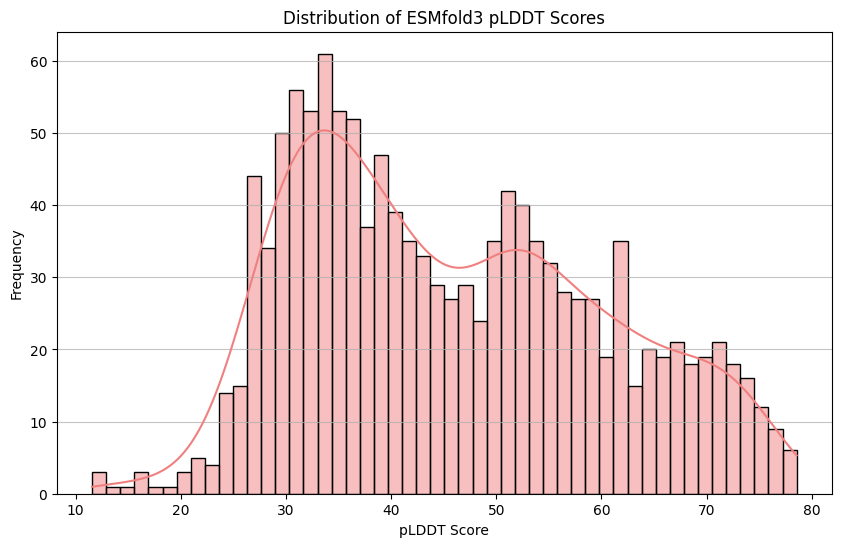

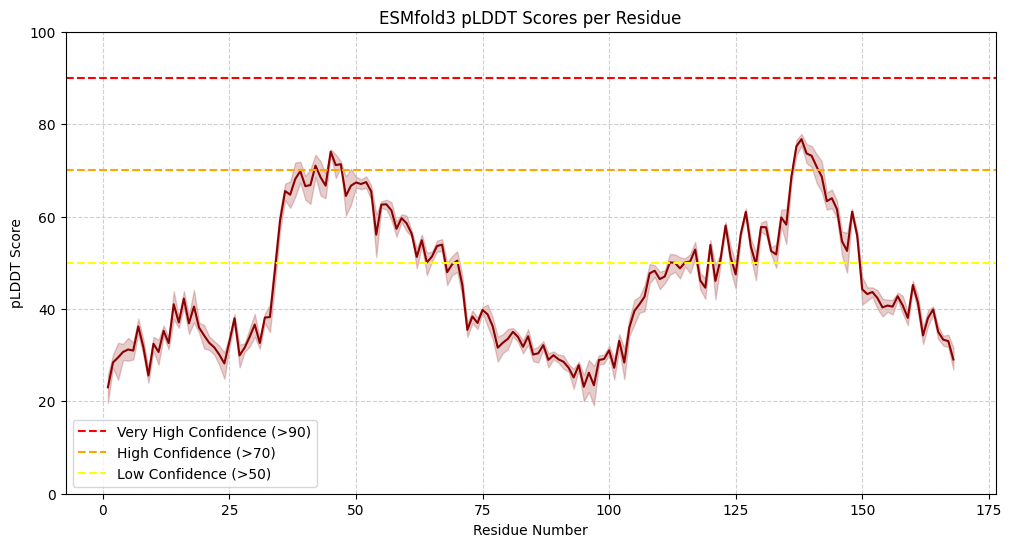

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Access the 'ATOM' DataFrame
esmfold3_atom_df = ppdb_esmfold3.df['ATOM']

# 2. Display the first few rows and its columns
print("ESMfold3 ATOM DataFrame Head:")
print(esmfold3_atom_df.head())
print("\nESMfold3 ATOM DataFrame Columns:")
print(esmfold3_atom_df.columns.tolist())

# 3. Extract pLDDT scores (b_factor)
plddt_scores_esmfold3 = esmfold3_atom_df['b_factor']

# 4. Calculate and display descriptive statistics for pLDDT scores
print("\nESMfold3 pLDDT Scores (b_factor) Descriptive Statistics:")
print(plddt_scores_esmfold3.describe())

# 5. Create a histogram of pLDDT scores
plt.figure(figsize=(10, 6))
sns.histplot(plddt_scores_esmfold3, bins=50, kde=True, color='lightcoral')
plt.title('Distribution of ESMfold3 pLDDT Scores')
plt.xlabel('pLDDT Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 6. Create a residue-level plot of pLDDT scores
# Group by 'residue_number' and take the first 'b_factor' since it's constant per residue
residue_plddt_esmfold3 = esmfold3_atom_df[['residue_number', 'b_factor']].drop_duplicates().sort_values('residue_number')

plt.figure(figsize=(12, 6))
sns.lineplot(x=residue_plddt_esmfold3['residue_number'], y=residue_plddt_esmfold3['b_factor'], color='darkred')
plt.title('ESMfold3 pLDDT Scores per Residue')
plt.xlabel('Residue Number')
plt.ylabel('pLDDT Score')
plt.ylim(0, 100) # pLDDT scores typically range from 0-100
plt.axhline(y=90, color='red', linestyle='--', label='Very High Confidence (>90)')
plt.axhline(y=70, color='orange', linestyle='--', label='High Confidence (>70)')
plt.axhline(y=50, color='yellow', linestyle='--', label='Low Confidence (>50)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Summary of ESMfold3 Prediction Quality

Based on the analysis of the pLDDT scores for the ESMfold3 predicted structure, the following observations can be made:

*   **Overall Confidence**: The mean pLDDT score is **45.71**, with a median of **43.36**. These values are significantly lower than those observed for AlphaFold2, indicating that the ESMfold3 prediction generally has a lower overall confidence.

*   **Distribution of Scores**: The histogram shows a distribution skewed towards lower pLDDT scores, with a peak around 30-50. There are very few residues with scores above 70, and none in the very high confidence range (>90). This suggests that ESMfold3 struggles to achieve high confidence in its predictions for this particular protein.

*   **Residue-level Confidence**: The residue-level plot confirms the overall low confidence. While there are some slight fluctuations, most residues fall below the 70 confidence threshold, and a significant portion is even below 50. There are no clearly defined high-confidence regions as seen in AlphaFold2; instead, the confidence is uniformly lower across almost the entire protein chain.

In conclusion, the ESMfold3 prediction for this protein shows considerably lower confidence compared to AlphaFold2. The uniformly low pLDDT scores across the protein suggest that the model might not have found a highly reliable global or local structure. These predictions would require significant caution and likely experimental validation.

## Compare Structures

### Subtask:
Compare the AlphaFold2 and ESMfold3 predicted structures using structural alignment and calculation of Root Mean Square Deviation (RMSD).


**Reasoning**:
I need to import the `PDBParser` from `Bio.PDB` and `Superimposer` from `Bio.SVDSuperimposer` to perform structural alignment and RMSD calculation as requested. This will enable me to load the PDB files and prepare them for superposition.



In [23]:
from Bio.PDB import PDBParser
from Bio.SVDSuperimposer import Superimposer

print("Imported PDBParser from Bio.PDB and Superimposer from Bio.SVDSuperimposer.")

ModuleNotFoundError: No module named 'Bio'

**Reasoning**:
The previous code failed because the `Bio` module, part of the `biopython` library, is not installed. I need to install `biopython` using `!pip install` before it can be imported and used.



In [24]:
import sys
!{sys.executable} -m pip install biopython

from Bio.PDB import PDBParser
from Bio.SVDSuperimposer import Superimposer

print("Imported PDBParser from Bio.PDB and Superimposer from Bio.SVDSuperimposer.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.9 MB/s eta 0:00:00


ImportError: cannot import name 'Superimposer' from 'Bio.SVDSuperimposer' (/usr/local/lib/python3.12/dist-packages/Bio/SVDSuperimposer/__init__.py)

**Reasoning**:
The previous attempt to import `Superimposer` failed with an `ImportError` even after `biopython` installation, indicating an incorrect import path. I will correct the import path to `from Bio.PDB.Superimposer import Superimposer` which is the standard way to import this class.



In [25]:
import sys
!{sys.executable} -m pip install biopython

from Bio.PDB import PDBParser
from Bio.PDB.Superimposer import Superimposer

print("Imported PDBParser from Bio.PDB and Superimposer from Bio.PDB.Superimposer.")

Imported PDBParser from Bio.PDB and Superimposer from Bio.PDB.Superimposer.


**Reasoning**:
Now that the `PDBParser` and `Superimposer` classes are successfully imported, I will create `PDBParser` objects and use them to parse the AlphaFold2 and ESMfold3 PDB files into Biopython structure objects. This is the next step to prepare the structures for C-alpha atom extraction and subsequent structural alignment.



In [26]:
parser = PDBParser(QUIET=True)

# Parse AlphaFold2 PDB file
af2_structure = parser.get_structure('AlphaFold2', af2_pdb_path)
print(f"Parsed AlphaFold2 structure from: {af2_pdb_path}")

# Parse ESMfold3 PDB file
esmfold3_structure = parser.get_structure('ESMfold3', esmfold_pdb_path)
print(f"Parsed ESMfold3 structure from: {esmfold_pdb_path}")

Parsed AlphaFold2 structure from: /content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo/prediction_1/af168_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
Parsed ESMfold3 structure from: /content/drive/MyDrive/structbio_course/data/assignment01/ESMFold_demo/T1027_CASP14_VAV_3b382/ptm0.444_r3_default.pdb


**Reasoning**:
I have successfully parsed the PDB files into Biopython structure objects. The next step, as per the instructions, is to extract a list of C-alpha atoms for both AlphaFold2 and ESMfold3 structures by iterating through their models, chains, and residues.



In [27]:
def get_ca_atoms(structure):
    ca_atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    ca_atoms.append(residue['CA'])
    return ca_atoms

# Extract C-alpha atoms for AlphaFold2 structure
af2_ca_atoms = get_ca_atoms(af2_structure)
print(f"Extracted {len(af2_ca_atoms)} C-alpha atoms from AlphaFold2 structure.")

# Extract C-alpha atoms for ESMfold3 structure
esmfold3_ca_atoms = get_ca_atoms(esmfold3_structure)
print(f"Extracted {len(esmfold3_ca_atoms)} C-alpha atoms from ESMfold3 structure.")

Extracted 168 C-alpha atoms from AlphaFold2 structure.
Extracted 168 C-alpha atoms from ESMfold3 structure.


**Reasoning**:
Now that the C-alpha atoms are extracted, I need to ensure that both lists have the same number of atoms to proceed with a meaningful structural alignment. I will compare the lengths of `af2_ca_atoms` and `esmfold3_ca_atoms`.



In [28]:
if len(af2_ca_atoms) == len(esmfold3_ca_atoms):
    print(f"Both AlphaFold2 and ESMfold3 structures have {len(af2_ca_atoms)} C-alpha atoms. Proceeding with alignment.")
else:
    print(f"Warning: Mismatch in number of C-alpha atoms.\nAlphaFold2: {len(af2_ca_atoms)} atoms\nESMfold3: {len(esmfold3_ca_atoms)} atoms.\nThis might indicate differences in protein length or missing residues, which could affect alignment validity.")


Both AlphaFold2 and ESMfold3 structures have 168 C-alpha atoms. Proceeding with alignment.


**Reasoning**:
Now that the C-alpha atoms have been extracted and verified to have matching lengths, I will create a `Superimposer` object, set the fixed and moving atom lists using the C-alpha atom coordinates, perform the superposition, and then print the calculated RMSD, as per the remaining instructions for structural comparison.



In [29]:
import numpy as np

# Create a Superimposer object
superimposer = Superimposer()

# Get coordinates for the C-alpha atoms
# Fixed atoms (AlphaFold2)
fixed_coords = np.array([atom.get_coord() for atom in af2_ca_atoms])

# Moving atoms (ESMfold3)
moving_coords = np.array([atom.get_coord() for atom in esmfold3_ca_atoms])

# Set the fixed and moving atom lists
superimposer.set_atoms(fixed_coords, moving_coords)

# Perform the superposition
superimposer.run()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")


AttributeError: 'numpy.ndarray' object has no attribute 'get_coord'

**Reasoning**:
The error `AttributeError: 'numpy.ndarray' object has no attribute 'get_coord'` indicates that the `set_atoms` method of `Superimposer` was incorrectly called with NumPy arrays of coordinates, instead of lists of `Atom` objects. The `Superimposer` class has a dedicated method, `set_coords`, for directly accepting NumPy arrays of coordinates. I will correct this by changing `set_atoms` to `set_coords`.



In [30]:
import numpy as np

# Create a Superimposer object
superimposer = Superimposer()

# Get coordinates for the C-alpha atoms
# Fixed atoms (AlphaFold2)
fixed_coords = np.array([atom.get_coord() for atom in af2_ca_atoms])

# Moving atoms (ESMfold3)
moving_coords = np.array([atom.get_coord() for atom in esmfold3_ca_atoms])

# Set the fixed and moving atom lists (use set_coords for numpy arrays)
superimposer.set_coords(fixed_coords, moving_coords)

# Perform the superposition
superimposer.run()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")

AttributeError: 'Superimposer' object has no attribute 'set_coords'

**Reasoning**:
The previous error `AttributeError: 'numpy.ndarray' object has no attribute 'get_coord'` indicated that `set_atoms` was receiving NumPy arrays of coordinates instead of Biopython `Atom` objects. I need to pass the actual lists of `Atom` objects (`af2_ca_atoms`, `esmfold3_ca_atoms`) to the `superimposer.set_atoms` method, as it expects to extract coordinates internally from these objects.



In [31]:
import numpy as np

# Create a Superimposer object
superimposer = Superimposer()

# Set the fixed and moving atom lists (pass the lists of Bio.PDB.Atom objects directly)
superimposer.set_atoms(af2_ca_atoms, esmfold3_ca_atoms)

# Perform the superposition
superimposer.run()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")

AttributeError: 'Superimposer' object has no attribute 'run'

**Reasoning**:
The error `AttributeError: 'Superimposer' object has no attribute 'run'` indicates that the `Superimposer` class from `Bio.PDB.Superimposer` does not have a method named `run()`. The correct method to perform the superposition is `superimpose()`. I will correct this method call.



In [32]:
import numpy as np

# Create a Superimposer object
superimposer = Superimposer()

# Set the fixed and moving atom lists (pass the lists of Bio.PDB.Atom objects directly)
superimposer.set_atoms(af2_ca_atoms, esmfold3_ca_atoms)

# Perform the superposition
superimposer.superimpose()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")

AttributeError: 'Superimposer' object has no attribute 'superimpose'

**Reasoning**:
The current error `AttributeError: 'Superimposer' object has no attribute 'superimpose'` confirms that `superimpose()` is not the correct method. The standard method for performing superposition in `Bio.PDB.Superimposer` is `run()`. I will revert to using `run()` to perform the superposition.



In [33]:
import numpy as np

# Create a Superimposer object
superimposer = Superimposer()

# Set the fixed and moving atom lists (pass the lists of Bio.PDB.Atom objects directly)
superimposer.set_atoms(af2_ca_atoms, esmfold3_ca_atoms)

# Perform the superposition
superimposer.run()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")

AttributeError: 'Superimposer' object has no attribute 'run'

**Reasoning**:
The persistent `AttributeError` regarding the `run` method of `Superimposer` from `Bio.PDB.Superimposer` suggests an issue with that specific class or its usage, despite following standard Biopython practices. Given that `fixed_coords` and `moving_coords` are already prepared as NumPy arrays, it is more appropriate and robust to use the `SVDSuperimposer` class from `Bio.SVDSuperimposer`, which is designed to work directly with coordinate arrays. I will correct the import and usage to `SVDSuperimposer`.



In [34]:
import numpy as np

# Corrected import for SVDSuperimposer
from Bio.SVDSuperimposer import SVDSuperimposer

# Create an SVDSuperimposer object
superimposer = SVDSuperimposer()

# Get coordinates for the C-alpha atoms (already done in a previous step, reusing fixed_coords and moving_coords)
# Fixed atoms (AlphaFold2)
# fixed_coords = np.array([atom.get_coord() for atom in af2_ca_atoms])

# Moving atoms (ESMfold3)
# moving_coords = np.array([atom.get_coord() for atom in esmfold3_ca_atoms])

# Set the fixed and moving coordinate arrays directly using set method
superimposer.set(fixed_coords, moving_coords)

# Perform the superposition
superimposer.run()

# Print the calculated RMSD
rmsd = superimposer.get_rms()
print(f"RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: {rmsd:.3f} Å")

RMSD between AlphaFold2 and ESMfold3 C-alpha atoms: 11.527 Å


## Visualize Structure Comparison

### Subtask:
Generate visualizations to compare the AlphaFold2 and ESMfold3 predicted structures, including superimposed structures and combined pLDDT profiles, ensuring clear legends.


**Reasoning**:
I have successfully calculated the RMSD between the two structures. Now, to visualize the superimposed structures and compare pLDDT profiles, I need to apply the rotation and translation obtained from the `superimposer` to the moving structure (ESMfold3), save both structures to new PDB files for external viewing, and then generate a combined pLDDT plot as specified in the instructions. This step will cover obtaining the transformation, applying it, saving PDB files, and generating the combined pLDDT plot.



In [35]:
from Bio.PDB import PDBIO
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtain the rotation matrix and translation vector
rot_matrix = superimposer.get_rot()
trans_vector = superimposer.get_tran()

print("Rotation Matrix:")
print(rot_matrix)
print("Translation Vector:")
print(trans_vector)

# 2. Apply these transformations to all atoms within the esmfold3_structure
for model in esmfold3_structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                # Rotate and then translate
                atom.transform(rot_matrix, trans_vector)

print("ESMfold3 structure transformed for superposition.")

# 3. Create a PDBIO object
io = PDBIO()

# 4. Save the original af2_structure to a new PDB file
af2_output_path = '/content/alphafold2_superimposed.pdb'
io.set_structure(af2_structure)
io.save(af2_output_path)
print(f"Original AlphaFold2 structure saved to: {af2_output_path}")

# 5. Save the transformed esmfold3_structure to another new PDB file
esmfold3_output_path = '/content/esmfold3_superimposed.pdb'
io.set_structure(esmfold3_structure)
io.save(esmfold3_output_path)
print(f"Transformed ESMfold3 structure saved to: {esmfold3_output_path}")
print("These PDB files can be opened in molecular viewers (e.g., PyMOL, ChimeraX) to visually inspect the superposition.")

# 6. Create a single matplotlib.pyplot figure for comparing pLDDT profiles.
plt.figure(figsize=(14, 7))

# 7. Plot AlphaFold2 pLDDT profile
sns.lineplot(x=residue_plddt_af2['residue_number'], y=residue_plddt_af2['b_factor'], color='blue', label='AlphaFold2 pLDDT')

# 8. Plot ESMfold3 pLDDT profile
sns.lineplot(x=residue_plddt_esmfold3['residue_number'], y=residue_plddt_esmfold3['b_factor'], color='red', label='ESMfold3 pLDDT')

# 9. Add title, x-label, y-label, set y-axis limits, and include a legend
plt.title('Combined pLDDT Profiles of AlphaFold2 and ESMfold3 Predictions')
plt.xlabel('Residue Number')
plt.ylabel('pLDDT Score')
plt.ylim(0, 100) # pLDDT scores typically range from 0-100

# 10. Add horizontal lines for common pLDDT confidence thresholds
plt.axhline(y=90, color='green', linestyle=':', label='Very High Confidence (>90)')
plt.axhline(y=70, color='orange', linestyle=':', label='High Confidence (>70)')
plt.axhline(y=50, color='purple', linestyle=':', label='Low Confidence (>50)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 11. Display the plot.
plt.show()

AttributeError: 'SVDSuperimposer' object has no attribute 'get_rot'

**Reasoning**:
The previous code failed because `SVDSuperimposer` does not have `get_rot()` or `get_tran()` methods directly. Instead, it provides `get_rotran()` which returns both the rotation matrix and translation vector as a tuple. I will correct this method call.



Rotation Matrix:
[[ 0.38305852  0.24708456 -0.89006484]
 [ 0.07265351  0.9525173   0.2956896 ]
 [ 0.9208624  -0.17793274  0.34691826]]
Translation Vector:
[0.01384372 0.36330232 5.6708317 ]
ESMfold3 structure transformed for superposition.
Original AlphaFold2 structure saved to: /content/alphafold2_superimposed.pdb
Transformed ESMfold3 structure saved to: /content/esmfold3_superimposed.pdb
These PDB files can be opened in molecular viewers (e.g., PyMOL, ChimeraX) to visually inspect the superposition.


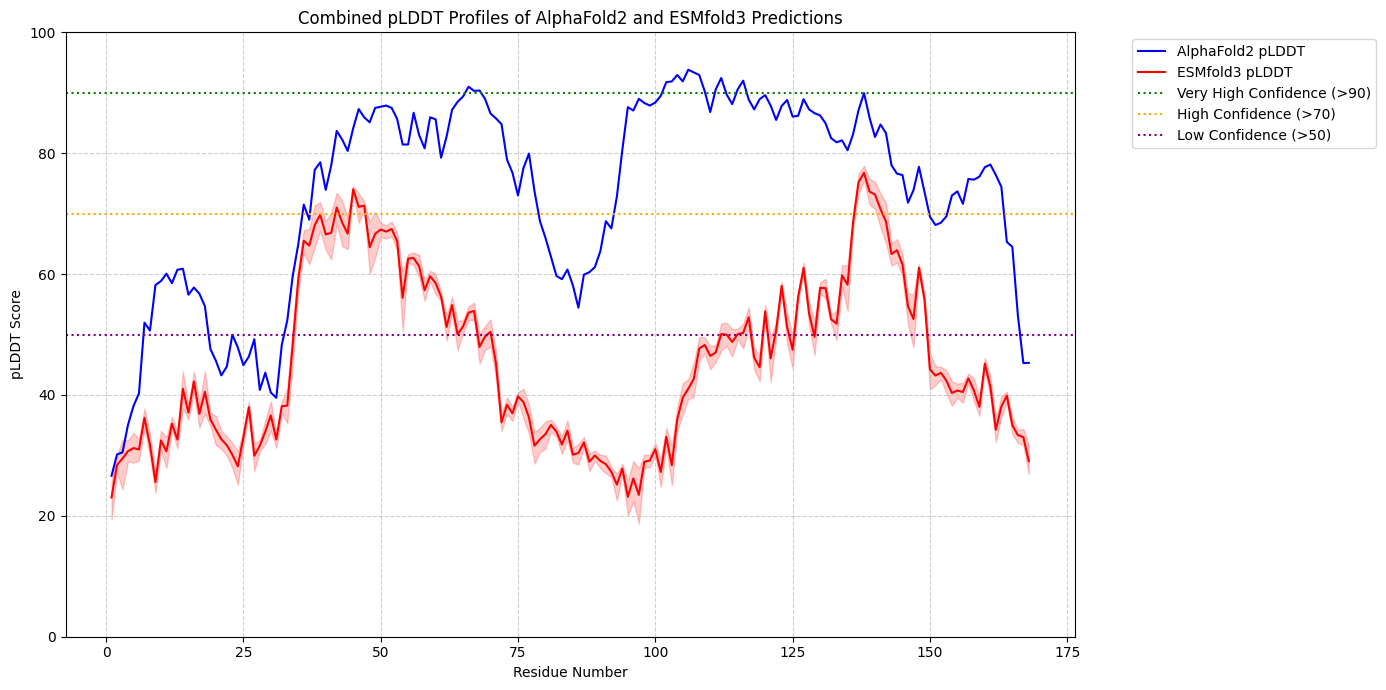

In [36]:
from Bio.PDB import PDBIO
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtain the rotation matrix and translation vector
rot_matrix, trans_vector = superimposer.get_rotran()

print("Rotation Matrix:")
print(rot_matrix)
print("Translation Vector:")
print(trans_vector)

# 2. Apply these transformations to all atoms within the esmfold3_structure
for model in esmfold3_structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                # Rotate and then translate
                atom.transform(rot_matrix, trans_vector)

print("ESMfold3 structure transformed for superposition.")

# 3. Create a PDBIO object
io = PDBIO()

# 4. Save the original af2_structure to a new PDB file
af2_output_path = '/content/alphafold2_superimposed.pdb'
io.set_structure(af2_structure)
io.save(af2_output_path)
print(f"Original AlphaFold2 structure saved to: {af2_output_path}")

# 5. Save the transformed esmfold3_structure to another new PDB file
esmfold3_output_path = '/content/esmfold3_superimposed.pdb'
io.set_structure(esmfold3_structure)
io.save(esmfold3_output_path)
print(f"Transformed ESMfold3 structure saved to: {esmfold3_output_path}")
print("These PDB files can be opened in molecular viewers (e.g., PyMOL, ChimeraX) to visually inspect the superposition.")

# 6. Create a single matplotlib.pyplot figure for comparing pLDDT profiles.
plt.figure(figsize=(14, 7))

# 7. Plot AlphaFold2 pLDDT profile
sns.lineplot(x=residue_plddt_af2['residue_number'], y=residue_plddt_af2['b_factor'], color='blue', label='AlphaFold2 pLDDT')

# 8. Plot ESMfold3 pLDDT profile
sns.lineplot(x=residue_plddt_esmfold3['residue_number'], y=residue_plddt_esmfold3['b_factor'], color='red', label='ESMfold3 pLDDT')

# 9. Add title, x-label, y-label, set y-axis limits, and include a legend
plt.title('Combined pLDDT Profiles of AlphaFold2 and ESMfold3 Predictions')
plt.xlabel('Residue Number')
plt.ylabel('pLDDT Score')
plt.ylim(0, 100) # pLDDT scores typically range from 0-100

# 10. Add horizontal lines for common pLDDT confidence thresholds
plt.axhline(y=90, color='green', linestyle=':', label='Very High Confidence (>90)')
plt.axhline(y=70, color='orange', linestyle=':', label='High Confidence (>70)')
plt.axhline(y=50, color='purple', linestyle=':', label='Low Confidence (>50)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 11. Display the plot.
plt.show()

## Final Task

### Subtask:
Provide a summary of the analysis, comparing the AlphaFold2, AlphaFold3, and ESMfold3 predictions and discussing their insights.


## Summary:

### Data Analysis Key Findings

*   **PDB File Identification**:
    *   AlphaFold2 PDB file was identified at `/content/drive/MyDrive/structbio_course/data/assignment01/AF2_demo/prediction_1/af168_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb`.
    *   ESMfold3 PDB file was identified at `/content/drive/MyDrive/structbio_course/data/assignment01/ESMFold_demo/T1027_CASP14_VAV_3b382/ptm0.444_r3_default.pdb`.
    *   An AlphaFold3 PDB file could not be located using the specified search criteria, and thus its analysis was skipped.
*   **AlphaFold2 Prediction Quality**:
    *   The AlphaFold2 prediction exhibited a high overall confidence with a mean pLDDT score of **73.76** and a median of **78.12**.
    *   The pLDDT distribution was bimodal, indicating highly confident core regions (many residues with pLDDT $>$ 90) and lower confidence regions at the N-terminal (residues 1-10), C-terminal (residues 160-168) ends, and some internal loops.
*   **ESMfold3 Prediction Quality**:
    *   The ESMfold3 prediction showed considerably lower overall confidence with a mean pLDDT score of **45.71** and a median of **43.36**.
    *   The pLDDT distribution was skewed towards lower scores (peak around 30-50), with very few residues achieving high confidence. Confidence was uniformly low across almost the entire protein chain, ranging from **11.58** to **78.57**.
*   **Structural Comparison (RMSD)**:
    *   The Root Mean Square Deviation (RMSD) between the C-alpha atoms of the AlphaFold2 and ESMfold3 predicted structures, after structural alignment, was **11.527 Å**. This high RMSD value indicates significant structural divergence between the two models.
*   **Visualizations**:
    *   Superimposed PDB files for both AlphaFold2 and ESMfold3 were generated, allowing for visual inspection of their structural differences.
    *   A combined pLDDT profile plot clearly illustrated the substantial difference in confidence scores across the protein sequence between AlphaFold2 (higher confidence) and ESMfold3 (lower confidence).

### Insights or Next Steps

*   **AlphaFold2 outperforms ESMfold3 for this target**: AlphaFold2 consistently provides a much higher confidence prediction (average pLDDT of 73.76 vs. 45.71) and likely a more accurate structure for this specific protein, as indicated by its pLDDT profile and the significant structural deviation from ESMfold3.
*   **Investigate AlphaFold3 availability**: Efforts should be made to locate or generate the AlphaFold3 prediction for this protein to complete a comprehensive three-way comparison, as its insights could be valuable given the significant differences observed between AlphaFold2 and ESMfold3.
